In [ ]:
!pip -q install -U "huggingface_hub>=0.23" pyarrow scikit-learn pandas numpy matplotlib seaborn

import warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from huggingface_hub import HfApi, hf_hub_download
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix,
                             cohen_kappa_score, jaccard_score)

SAMPLE_SIZE = 20000
RANDOM_STATE = 42

In [ ]:
REPO = "OpenClaw/clawhub-security-signals"
REV  = "refs/convert/parquet"

print("Listing Parquet files on the Hub...")
api = HfApi()
all_files = api.list_repo_files(REPO, repo_type="dataset", revision=REV)
parquet_files = [f for f in all_files if f.endswith(".parquet")]

def load_split(split):
    """Download + concat all Parquet shards for a given split into a DataFrame."""
    shards = [f for f in parquet_files
              if f.split("/")[-2] == split]
    if not shards:
        raise ValueError(f"No parquet files for split '{split}'. Found: {parquet_files[:5]}")
    frames = []
    for f in shards:
        local = hf_hub_download(REPO, f, repo_type="dataset", revision=REV)
        frames.append(pd.read_parquet(local))
    return pd.concat(frames, ignore_index=True)

print("Downloading train + test splits (first run pulls the data)...")
train_df = load_split("train")
test_df  = load_split("test")

if SAMPLE_SIZE:
    train_df = train_df.sample(min(SAMPLE_SIZE, len(train_df)),
                               random_state=RANDOM_STATE).reset_index(drop=True)

print(f"\nTrain rows in use: {len(train_df):,} | Test rows: {len(test_df):,}")
print("Columns:", list(train_df.columns))

In [ ]:
print("\n=== ClawScan verdict distribution (train) ===")
print(train_df["clawscan_verdict"].value_counts(normalize=True).mul(100).round(2))

print("\n=== SkillSpector severity distribution ===")
print(train_df["skillspector_severity"].value_counts(dropna=False))

sample = train_df.iloc[0]
print(f"\nExample skill: {sample['skill_slug']} (v{sample['skill_version']})")
print(f"Verdict: {sample['clawscan_verdict']} | Summary: {sample['clawscan_summary']}")
print("SKILL.md (first 400 chars):\n", str(sample["skill_md_content"])[:400])

POSITIVE = {"suspicious", "malicious"}
def is_pos(series):
    return series.fillna("").isin(POSITIVE).astype(int)

an = train_df.copy()
an["vt_pos"]     = is_pos(an["virustotal_status"])
an["static_pos"] = is_pos(an["static_status"])
an["spec_pos"]   = is_pos(an["skillspector_status"])

print("\n=== Scanner positive rates ===")
for col, name in [("vt_pos","VirusTotal"),("static_pos","Static"),("spec_pos","SkillSpector")]:
    print(f"  {name:12s}: {an[col].mean()*100:5.2f}% positive")

def pattern(r):
    tags = []
    if r.vt_pos: tags.append("VT")
    if r.static_pos: tags.append("Static")
    if r.spec_pos: tags.append("SkillSpector")
    return "None" if not tags else " + ".join(tags)

an["pattern"] = an.apply(pattern, axis=1)
print("\n=== Positive-signal overlap patterns ===")
print(an["pattern"].value_counts(normalize=True).mul(100).round(2))

print("\n=== Pairwise agreement (low = scanners inspect different surfaces) ===")
pairs = [("vt_pos","static_pos","VT vs Static"),
         ("vt_pos","spec_pos","VT vs SkillSpector"),
         ("static_pos","spec_pos","Static vs SkillSpector")]
for a, b, label in pairs:
    j = jaccard_score(an[a], an[b], zero_division=0)
    k = cohen_kappa_score(an[a], an[b])
    print(f"  {label:26s} Jaccard={j:.3f}  Cohen's kappa={k:.3f}")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
order = ["clean","suspicious","malicious"]

sns.countplot(data=train_df, x="clawscan_verdict", order=order, ax=axes[0,0], palette="viridis")
axes[0,0].set_title("ClawScan verdict distribution"); axes[0,0].set_yscale("log")

rates = {"VirusTotal":an["vt_pos"].mean(), "Static":an["static_pos"].mean(),
         "SkillSpector":an["spec_pos"].mean()}
axes[0,1].bar(rates.keys(), [v*100 for v in rates.values()], color="#d95f02")
axes[0,1].set_title("Scanner positive rate (%)"); axes[0,1].set_ylabel("% flagged")

pc = an["pattern"].value_counts()
axes[1,0].barh(pc.index, pc.values, color="#7570b3")
axes[1,0].set_title("Positive-signal overlap patterns"); axes[1,0].invert_yaxis()

sns.boxplot(data=train_df, x="clawscan_verdict", y="skillspector_score",
            order=order, ax=axes[1,1], palette="viridis")
axes[1,1].set_title("SkillSpector score by verdict")
plt.tight_layout(); plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.4/684.4 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 54.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incomp

default/train/0000.parquet:   0%|          | 0.00/335M [00:00<?, ?B/s]

default/train/0001.parquet:   0%|          | 0.00/87.4M [00:00<?, ?B/s]

default/test/0000.parquet:   0%|          | 0.00/63.8M [00:00<?, ?B/s]


Train rows in use: 20,000 | Test rows: 6,747
Columns: ['id', 'skill_slug', 'skill_version', 'skill_md_content', 'skill_bundle_content', 'clawscan_verdict', 'clawscan_confidence', 'clawscan_model', 'clawscan_summary', 'static_status', 'static_finding_count', 'static_reason_codes', 'virustotal_status', 'virustotal_malicious_count', 'virustotal_suspicious_count', 'virustotal_harmless_count', 'virustotal_undetected_count', 'skillspector_status', 'skillspector_score', 'skillspector_severity', 'skillspector_issue_count', 'skillspector_issue_codes', 'skillspector_issue_categories', 'clawscan_context', 'split']

=== ClawScan verdict distribution (train) ===
clawscan_verdict
clean         61.81
suspicious    37.88
malicious      0.31
Name: proportion, dtype: float64

=== SkillSpector severity distribution ===
skillspector_severity
LOW         9883
MEDIUM      3936
CRITICAL    3808
HIGH        1994
None         379
Name: count, dtype: int64

Example skill: ryan-zry/flightai (v1.0.0)
Verdict: su

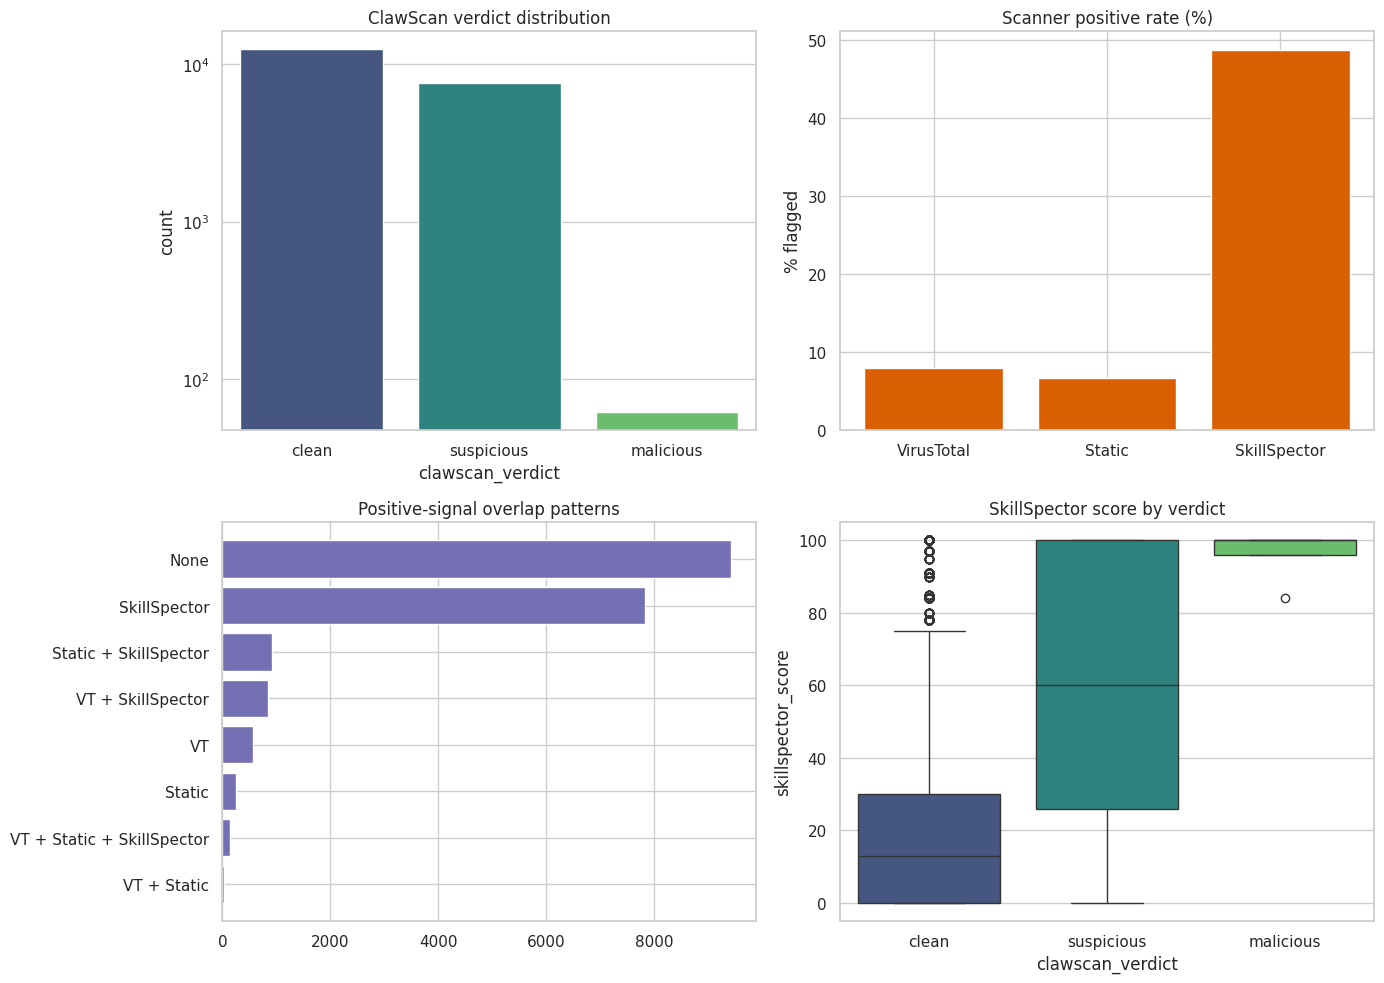


Training classifier (SKILL.md text + scanner numbers -> verdict)...

=== Test-set classification report ===
              precision    recall  f1-score   support

       clean      0.831     0.805     0.817      4118
   malicious      0.375     0.375     0.375        16
  suspicious      0.706     0.741     0.723      2613

    accuracy                          0.779      6747
   macro avg      0.637     0.640     0.638      6747
weighted avg      0.781     0.779     0.780      6747



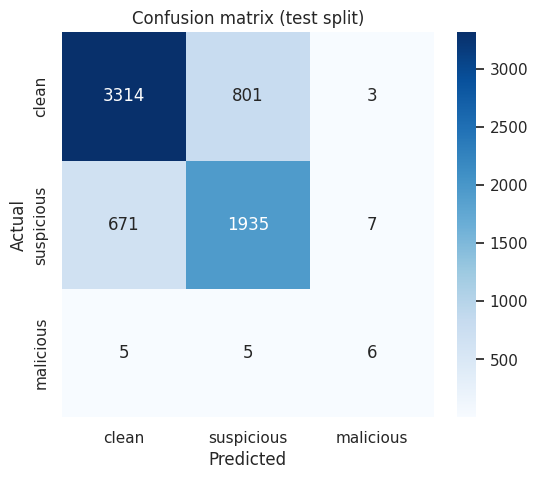


=== Sample misclassifications ===
- baptiste00001/icalendar-events-parser true=clean      pred=suspicious
- otman-ai/tikto-automation           true=clean      pred=suspicious
- darrenluo/coinfound-skill           true=clean      pred=suspicious
- nengnengz/baoyu-article-illustrator-2 true=clean      pred=suspicious
- alfathsyahrian/idx-scalper          true=clean      pred=suspicious
- xuya227939/tiktok-research-kit      true=suspicious pred=clean     
- fuczy/clawd-code-reviewer           true=suspicious pred=clean     
- oldairman/xia-china-stock           true=clean      pred=suspicious

Done. Set SAMPLE_SIZE=None for the full dataset.


In [2]:
TEXT_COL = "skill_md_content"
NUM_COLS = ["skillspector_score", "static_finding_count",
            "skillspector_issue_count", "virustotal_malicious_count"]
TARGET   = "clawscan_verdict"

def prep(df):
    out = df.copy()
    out[TEXT_COL] = out[TEXT_COL].fillna("").astype(str).str.slice(0, 6000)
    for c in NUM_COLS:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

train_p, test_p = prep(train_df), prep(test_df)
get_text = FunctionTransformer(lambda X: X[TEXT_COL].values, validate=False)

text_pipe = Pipeline([
    ("select", get_text),
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                              min_df=3, sublinear_tf=True)),
])
num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value=0)),
    ("scale", StandardScaler()),
])
features = ColumnTransformer([
    ("text", text_pipe, [TEXT_COL]),
    ("num", num_pipe, NUM_COLS),
])
clf = Pipeline([
    ("features", features),
    ("model", LogisticRegression(max_iter=2000, C=4.0,
                                 class_weight="balanced",
                                 multi_class="multinomial")),
])

print("\nTraining classifier (SKILL.md text + scanner numbers -> verdict)...")
clf.fit(train_p[[TEXT_COL] + NUM_COLS], train_p[TARGET])

pred = clf.predict(test_p[[TEXT_COL] + NUM_COLS])
print("\n=== Test-set classification report ===")
print(classification_report(test_p[TARGET], pred, digits=3))

cm = confusion_matrix(test_p[TARGET], pred, labels=order)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=order, yticklabels=order)
plt.title("Confusion matrix (test split)"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

test_out = test_p[["skill_slug", TARGET, "clawscan_summary"]].copy()
test_out["pred"] = pred
errors = test_out[test_out[TARGET] != test_out["pred"]].head(8)
print("\n=== Sample misclassifications ===")
for _, r in errors.iterrows():
    print(f"- {r['skill_slug']:35s} true={r[TARGET]:10s} pred={r['pred']:10s}")

print("\nDone. Set SAMPLE_SIZE=None for the full dataset.")